# Drogued drifter with CMEMS Baltic Sea currents

We run the drifter simulation using real ocean current data from the Copernicus
Marine Service. The data file `ds_baltic.nc` is created by notebook
`01_download_baltic_data`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from functools import partial

from drogued_drifters import DroguedDrifter

## Load data and extract a local velocity profile

We pick a location near Kiel Bight (10.9°E, 54.9°N) and extract the vertical
velocity profile there. This gives us a 1-D depth profile of `uo` and `vo` that
we can interpolate during the simulation.

In [2]:
ds = xr.open_dataset("ds_baltic.nc")

ds_local = (
    ds[["uo", "vo"]]
    .sel(latitude=54.9, longitude=10.9, method="nearest")
    .sel(depth=slice(0, 10))
    .compute()
)

ds_local

<xarray.Dataset> Size: 88B
Dimensions:    (depth: 6)
Coordinates:
  * depth      (depth) float32 24B 0.5016 1.516 2.548 3.602 4.684 5.8
    latitude   float32 4B 54.91
    longitude  float32 4B 10.9
    time       datetime64[ns] 8B 2025-07-01
Data variables:
    uo         (depth) float32 24B 0.3831 0.3844 0.365 0.349 0.3436 0.334
    vo         (depth) float32 24B 0.7712 0.7589 0.6695 0.627 0.5924 0.5573
Attributes: (12/19)
    Conventions:               CF-1.0
    comment:                   Data on cropped native product grid. Horizonta...
    compression:               yes
    contact:                   servicedesk.cmems@mercator-ocean.eu
    creation_date:             2024-11-25 17:05:09
    easternmost_longitude:     30.208656311035156
    ...                        ...
    southernmost_latitude:     53.008296966552734
    start_date:                2024-11-30 12:00:00
    stop_date:                 2024-11-30 12:00:00
    title:                     CMEMS NEMO daily integrated model fields
    westernmost_longitude:     9.041582107543945
    copernicusmarine_version:  2.3.0

## Define `get_uv` from the dataset

The `get_uv` callback looks up velocity at the surface (depth=0) and at drogue
depth from the local profile. We use `functools.partial` to bind the dataset,
so the drifter only sees the standard `(*, t, z_d, y_b, x_b)` signature.

In [3]:
def get_uv_from_ds(*, t, z_d, y_b, x_b, ds_local):
    """Look up currents from a pre-extracted depth profile."""
    U_b = float(ds_local["uo"].sel(depth=0.0, method="nearest").values)
    V_b = float(ds_local["vo"].sel(depth=0.0, method="nearest").values)
    U_d = float(ds_local["uo"].sel(depth=z_d, method="nearest").values)
    V_d = float(ds_local["vo"].sel(depth=z_d, method="nearest").values)
    return U_b, V_b, U_d, V_d

## Set up drifters

Again, we compare a complete drifter against a buoy-only drifter to see the
effect of the drogue on the trajectory.

In [4]:
get_uv = partial(get_uv_from_ds, ds_local=ds_local)

drifter_complete = DroguedDrifter(
    m_b=1.3,
    m_d=1.3,
    k_b=20,
    k_d=200,
    get_uv=get_uv,
)

drifter_buoy = DroguedDrifter(
    m_b=1.3,
    m_d=0.01,
    k_b=20,
    k_d=0.01,
    get_uv=get_uv,
)

## Integrate and plot

In [5]:
y0 = np.array([0.0, 0.0, 3 * np.pi / 4, 0.0, 0, 0, 0, 0])

T = 1800.0
dt = 5.0
t_eval = np.arange(0.0, T + dt, dt)

In [6]:
sol_complete = drifter_complete.get_full_solution((0, T), y0, t_eval=t_eval)
sol_buoy = drifter_buoy.get_full_solution((0, T), y0, t_eval=t_eval)

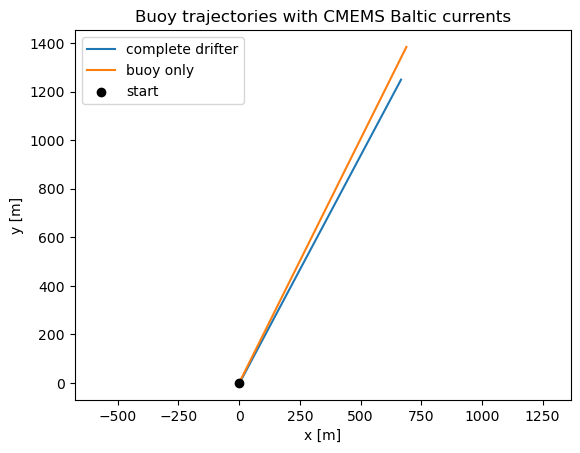

In [7]:
plt.plot(sol_complete.y[0], sol_complete.y[1], label="complete drifter")
plt.plot(sol_buoy.y[0], sol_buoy.y[1], label="buoy only")
plt.scatter([y0[0]], [y0[1]], color="k", zorder=5, label="start")
plt.axis("equal")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.legend()
plt.title("Buoy trajectories with CMEMS Baltic currents");

## Tether angle

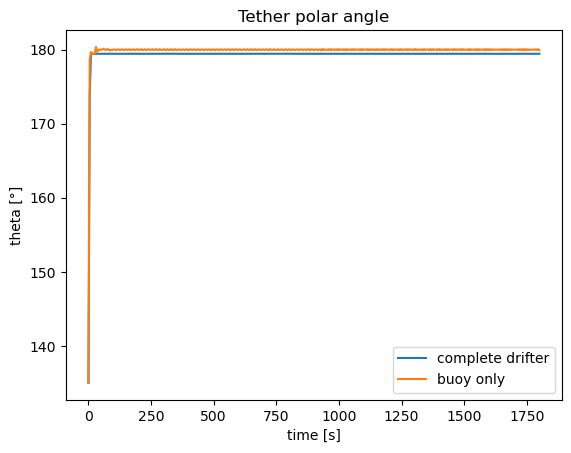

In [8]:
plt.plot(sol_complete.t, np.degrees(sol_complete.y[2]), label="complete drifter")
plt.plot(sol_buoy.t, np.degrees(sol_buoy.y[2]), label="buoy only")
plt.xlabel("time [s]")
plt.ylabel("theta [°]")
plt.legend()
plt.title("Tether polar angle");